In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fastpredictor/solar-power-generation-and-meteorological-data/Lahore_Single_Panel_Dataset_with_Meteorological_Datas.csv


In [115]:
import pandas as pd 
df=pd.read_csv("/kaggle/input/datasets/fastpredictor/solar-power-generation-and-meteorological-data/Lahore_Single_Panel_Dataset_with_Meteorological_Datas.csv")
dropped=df.drop("Prectotland", axis=1)
dropped["TimeStamp"] = pd.to_datetime(dropped["TimeStamp"])
dropped = dropped.set_index("TimeStamp")


In [116]:
dropped[:10]


,Power,Temperature,Rhoa,Irradiance (G),Irradiance (A),Cloud
TimeStamp,,,,,,
2014-10-20 12:00:00,480.434911,30.565,1.138,706.618,1014.074,0.0
2014-10-20 13:00:00,441.050889,30.998,1.135,640.765,939.703,0.0
2014-10-20 14:00:00,349.804093,30.801,1.133,484.715,792.593,0.0
2014-10-20 15:00:00,218.694815,30.226,1.132,320.429,582.943,0.0
2014-10-20 16:00:00,98.935342,28.270,1.133,143.503,324.811,0.0
2014-10-20 17:00:00,14.467491,25.249,1.135,17.009,57.536,0.0
2014-10-20 18:00:00,0.000000,24.117,1.138,0.000,0.000,0.0
2014-10-20 19:00:00,0.000000,23.358,1.141,0.000,0.000,0.0
2014-10-20 20:00:00,0.000000,22.625,1.144,0.000,0.000,0.0


DATA CLEANING

-Data Inspection

In [123]:
dropped.head()


,Power,Temperature,Rhoa,Irradiance (G),Irradiance (A),Cloud
TimeStamp,,,,,,
2014-10-20 12:00:00,480.434911,30.565,1.138,706.618,1014.074,0.0
2014-10-20 13:00:00,441.050889,30.998,1.135,640.765,939.703,0.0
2014-10-20 14:00:00,349.804093,30.801,1.133,484.715,792.593,0.0
2014-10-20 15:00:00,218.694815,30.226,1.132,320.429,582.943,0.0
2014-10-20 16:00:00,98.935342,28.270,1.133,143.503,324.811,0.0


In [124]:
dropped.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1745 entries, 2014-10-20 12:00:00 to 2015-01-01 04:00:00
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Power           1745 non-null   float64
 1   Temperature     1745 non-null   float64
 2   Rhoa            1745 non-null   float64
 3   Irradiance (G)  1745 non-null   float64
 4   Irradiance (A)  1745 non-null   float64
 5   Cloud           1745 non-null   float64
dtypes: float64(6)
memory usage: 95.4 KB


In [125]:
dropped.describe()

,Power,Temperature,Rhoa,Irradiance (G),Irradiance (A),Cloud
count,1745.000000,1745.000000,1745.000000,1745.000000,1745.000000,1745.000000
mean,86.676551,17.115997,1.178573,149.092436,243.547589,0.177268
std,128.513666,6.556680,0.024486,217.111712,331.140657,0.313351
min,0.000000,3.415000,1.130000,0.000000,0.000000,0.000000
25%,0.000000,12.115000,1.159000,0.000000,0.000000,0.000000
50%,0.000000,16.542000,1.178000,0.000000,0.000000,0.000000
75%,165.966518,21.898000,1.196000,294.611000,569.091000,0.181000
max,480.434911,32.357000,1.237000,719.652000,1014.074000,0.987000


-checking for Missing values
-wrong data type
-unusual ranges



In [127]:
#Checking for missing values
dropped.isnull().sum()

Power             0
Temperature       0
Rhoa              0
Irradiance (G)    0
Irradiance (A)    0
Cloud             0
dtype: int64

In [128]:
dropped = dropped.dropna()

Outlier Detection and Treatment

In [79]:
df = df[df["Irradiance (G)"] >= 0]
df = df[df["Irradiance (A)"] >= 0]

,Power,Temperature,Rhoa,Irradiance (G),Irradiance (A),Cloud
TimeStamp,,,,,,
2014-10-20 12:00:00,480.434911,30.565,1.138,706.618,1014.074,0.0
2014-10-20 13:00:00,441.050889,30.998,1.135,640.765,939.703,0.0
2014-10-20 14:00:00,349.804093,30.801,1.133,484.715,792.593,0.0
2014-10-20 15:00:00,218.694815,30.226,1.132,320.429,582.943,0.0
2014-10-20 16:00:00,98.935342,28.270,1.133,143.503,324.811,0.0
...,...,...,...,...,...,...
2015-01-01 00:00:00,0.000000,8.914,1.208,0.000,0.000,0.0
2015-01-01 01:00:00,0.000000,7.596,1.211,0.000,0.000,0.0
2015-01-01 02:00:00,0.000000,6.780,1.214,0.000,0.000,0.0


Feature Engineering

CREATION OF TIME BASED FEATURE

In [134]:
dropped["Hour"] = dropped.index.hour
dropped["Month"] = dropped.index.month
dropped["Is_Day"] = ((dropped.index.hour >= 6) & (dropped.index.hour <= 18)).astype(int)

In [135]:
dropped[:10]

,Power,Temperature,Rhoa,Irradiance (G),Irradiance (A),Cloud,Hour,Month,Is_Day
TimeStamp,,,,,,,,,
2014-10-20 12:00:00,480.434911,30.565,1.138,706.618,1014.074,0.0,12,10,1
2014-10-20 13:00:00,441.050889,30.998,1.135,640.765,939.703,0.0,13,10,1
2014-10-20 14:00:00,349.804093,30.801,1.133,484.715,792.593,0.0,14,10,1
2014-10-20 15:00:00,218.694815,30.226,1.132,320.429,582.943,0.0,15,10,1
2014-10-20 16:00:00,98.935342,28.270,1.133,143.503,324.811,0.0,16,10,1
2014-10-20 17:00:00,14.467491,25.249,1.135,17.009,57.536,0.0,17,10,1
2014-10-20 18:00:00,0.000000,24.117,1.138,0.000,0.000,0.0,18,10,1
2014-10-20 19:00:00,0.000000,23.358,1.141,0.000,0.000,0.0,19,10,0
2014-10-20 20:00:00,0.000000,22.625,1.144,0.000,0.000,0.0,20,10,0


FEATURE SELECTION

In [136]:
Y_features=dropped.drop(["Temperature","Rhoa", "Cloud","Irradiance (G)","Irradiance (A)"	,"Hour","Is_Day",	"Month"], axis=1)
Y_features

,Power
TimeStamp,
2014-10-20 12:00:00,480.434911
2014-10-20 13:00:00,441.050889
2014-10-20 14:00:00,349.804093
2014-10-20 15:00:00,218.694815
2014-10-20 16:00:00,98.935342
...,...
2015-01-01 00:00:00,0.000000
2015-01-01 01:00:00,0.000000
2015-01-01 02:00:00,0.000000


In [138]:
X_features=["Temperature","Rhoa","Irradiance (G)","Irradiance (A)"	,"Hour","Is_Day","Month", "Cloud"]
X=dropped[X_features]
X

,Temperature,Rhoa,Irradiance (G),Irradiance (A),Hour,Is_Day,Month,Cloud
TimeStamp,,,,,,,,
2014-10-20 12:00:00,30.565,1.138,706.618,1014.074,12,1,10,0.0
2014-10-20 13:00:00,30.998,1.135,640.765,939.703,13,1,10,0.0
2014-10-20 14:00:00,30.801,1.133,484.715,792.593,14,1,10,0.0
2014-10-20 15:00:00,30.226,1.132,320.429,582.943,15,1,10,0.0
2014-10-20 16:00:00,28.270,1.133,143.503,324.811,16,1,10,0.0
...,...,...,...,...,...,...,...,...
2015-01-01 00:00:00,8.914,1.208,0.000,0.000,0,0,1,0.0
2015-01-01 01:00:00,7.596,1.211,0.000,0.000,1,0,1,0.0
2015-01-01 02:00:00,6.780,1.214,0.000,0.000,2,0,1,0.0


In [139]:
Y_features=dropped.Power
Y_features

TimeStamp
2014-10-20 12:00:00    480.434911
2014-10-20 13:00:00    441.050889
2014-10-20 14:00:00    349.804093
2014-10-20 15:00:00    218.694815
2014-10-20 16:00:00     98.935342
                          ...    
2015-01-01 00:00:00      0.000000
2015-01-01 01:00:00      0.000000
2015-01-01 02:00:00      0.000000
2015-01-01 03:00:00      0.000000
2015-01-01 04:00:00      0.000000
Name: Power, Length: 1745, dtype: float64

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


In [142]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y_features, train_size=0.8, random_state=42)

In [143]:
X_train.shape, X_test.shape

((1396, 8), (349, 8))

In [144]:
X_test[:]

,Temperature,Rhoa,Irradiance (G),Irradiance (A),Hour,Is_Day,Month,Cloud
TimeStamp,,,,,,,,
2014-11-04 17:00:00,22.242,1.148,6.372,23.642,17,1,11,0.051
2014-11-03 20:00:00,19.878,1.161,0.000,0.000,20,0,11,0.690
2014-12-26 10:00:00,17.295,1.199,488.053,716.510,10,1,12,0.000
2014-10-23 10:00:00,29.512,1.142,590.378,914.495,10,1,10,0.936
2014-11-24 17:00:00,17.890,1.163,0.821,3.765,17,1,11,0.046
...,...,...,...,...,...,...,...,...
2014-12-15 07:00:00,9.199,1.220,41.091,118.167,7,1,12,0.017
2014-11-11 16:00:00,23.389,1.150,105.332,227.073,16,1,11,0.000
2014-12-19 05:00:00,6.692,1.230,0.000,0.000,5,0,12,0.932


In [145]:
Y_train.shape, Y_test.shape

((1396,), (349,))

In [146]:
Model=RandomForestRegressor(n_estimators=100, criterion="squared_error",random_state=40)

In [147]:
Model.fit(X_train, Y_train)

RandomForestRegressor(random_state=40)

In [148]:
y_pred=Model.predict(X_test)
y_pred.size


349

In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = Model.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
r2 = r2_score(Y_test, y_pred)

print(mae, rmse, r2)

10.830099532789394 25.326142336638714 0.9632387647021791


LINE PLOT

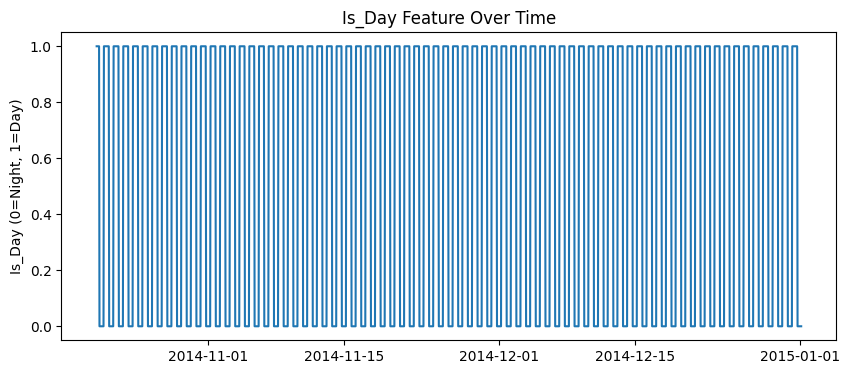

In [152]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(dropped.index, dropped["Is_Day"])
plt.title("Is_Day Feature Over Time")
plt.ylabel("Is_Day (0=Night, 1=Day)")
plt.show()

SCATTER PLOT

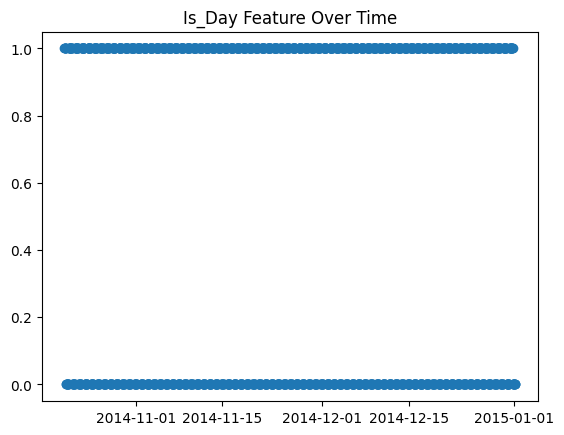

In [153]:
plt.scatter(dropped.index, dropped["Is_Day"])
plt.title("Is_Day Feature Over Time")
plt.show()

SAVING THE MODEL


In [157]:
import joblib
model=joblib.dump(Model, "/kaggle/working/solar_model.pkl")

In [158]:
import os
print(os.listdir())

['solar_model.pkl', '.virtual_documents', 'model.pkl']
